[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eirasf/GCED-AA2/blob/main/es/lab5/lab5.ipynb)
# Práctica 5: Optimización de redes neuronales


En este laboratorio trabajaremos con el mismo conjunto de datos que hemos utilizado hasta ahora. Carga todo el conjunto en un solo dataloader (en este laboratorio solo nos ocuparemos de estudiar el ajuste en entrenamiento, no la generalización).

In [17]:
# TODO: Carga los datos
import seaborn as sns
import pandas as pd
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset
df = sns.load_dataset('titanic')

# 2. Preprocesamiento básico
# Columnas con las que trabajaremos para la predicción de supervivencia (survived)
# Eliminamos redundancias y columnas con demasiados nulos (como deck)
columns_to_keep = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
X = df[columns_to_keep].copy()
y = df['survived'].values

# Imputar valores faltantes
X['age'] = X['age'].fillna(X['age'].median())
X['embarked'] = X['embarked'].fillna(X['embarked'].mode()[0])

# Codificar variables categóricas
X = pd.get_dummies(X, columns=['sex', 'embarked'], drop_first=True)

# Convertir todo a float32 para PyTorch
X_values = X.values.astype(np.float32)
y_values = y.astype(np.float32)

# Escalar características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_values)

# 3. Crear TensorDataset y DataLoader
tensor_x = torch.tensor(X_scaled, dtype=torch.float32)
tensor_y = torch.tensor(y_values, dtype=torch.float32).unsqueeze(1)

dataset = TensorDataset(tensor_x, tensor_y)
# Cargamos todo en un único dataloader
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"Datos cargados correctamente. Dimensiones de entrada: {tensor_x.shape}")

Datos cargados correctamente. Dimensiones de entrada: torch.Size([891, 8])


Usaremos la misma arquitectura, función para el aprendizaje, función para evaluación y función de coste que en los laboratorios anteriores. Haz las declaraciones necesarias en la siguiente celda.

Adapta la función `train_model` para que el parámetro `val_loader` pueda ser `None`, en cuyo caso no se calcula la pérdida en validación y se devuelve una lista vacía en la segunda componente de la tupla.

In [18]:
# TODO - Declara las funciones, la arquitectura y la función de pérdida a utilizar
import torch.nn as nn
import torch.optim as optim

# Definición de la arquitectura de la red corregida con capas ocultas 20, 10, 5
class TitanicNet(nn.Module):
    def __init__(self, input_dim):
        super(TitanicNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 20),
            nn.ReLU(),
            nn.Linear(20, 10),
            nn.ReLU(),
            nn.Linear(10, 5),
            nn.ReLU(),
            nn.Linear(5, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

# Función de pérdida
criterion = nn.BCELoss()

# Función de evaluación de precisión (accuracy)
def evaluate_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            outputs = model(inputs)
            predicted = (outputs >= 0.5).float()
            correct += (predicted == targets).sum().item()
            total += targets.size(0)
    return correct / total

# Función para el aprendizaje adaptada para que val_loader pueda ser None
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=200, scheduler=None):
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        if val_loader is not None:
            model.eval()
            running_val_loss = 0.0
            with torch.no_grad():
                for inputs, targets in val_loader:
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                    running_val_loss += loss.item() * inputs.size(0)
            epoch_val_loss = running_val_loss / len(val_loader.dataset)
            val_losses.append(epoch_val_loss)

        if scheduler is not None:
            scheduler.step()

    return train_losses, val_losses

Con todo esto listo, haremos una comparativa de los distintos optimizadores que nos ofrece `torch`.

En primer lugar haremos un entrenamiento con un optimizador SGD sin momentum. Instancia el modelo y un optimizador `optim.SGD`. Haz el entrenamiento y muestra la curva de aprendizaje. Prueba distintos valores de *learning rate*. Guarda las curvas de aprendizaje en un diccionario para mostrarlas todas en un mismo gráfico.

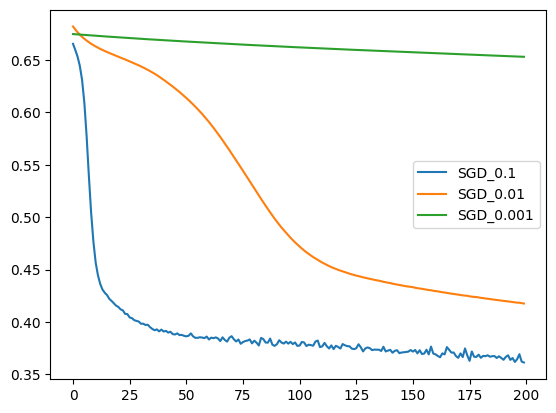

In [19]:
import matplotlib.pyplot as plt

lrs_a_explorar = [0.1, 0.01, 0.001] # TODO - Cambia esta lista para incluir los valores que consideres
histories = {}

# Determinar la dimensión de entrada a partir del dataset
input_dim = tensor_x.shape[1]

for lr in lrs_a_explorar:
    model = TitanicNet(input_dim)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    train_losses, _ = train_model(model, train_loader, None, criterion, optimizer, epochs=200)
    train_accuracy = evaluate_accuracy(model, train_loader)

    # TODO: Guarda el history del entrenamiento
    histories[f'SGD_{lr}'] = {'loss_history': train_losses, 'accuracy_history': train_accuracy}

# Mostramos en gráficas las curvas de aprendizaje que tengamos acumuladas en histories
for k in histories:
    plt.plot(histories[k]['loss_history'], label=k)
plt.legend()
plt.show()

## Comparativas

Repite todo el proceso de entrenamiento realizando cada uno de estos cambios. Haz varias pruebas hasta encontrar valores adecuados. No resetees el kernel ni vuelvas a ejecutar las dos primeras celdas entre las distintas pruebas, o perderás la posibilidad de comparar las curvas de aprendizaje. Recuerda modificar la etiqueta de la curva de cada prueba en la gráfica cuando añadas registros a `histories`.

1. **Tamaño del lote**: Modifica el tamaño de lote al crear el dataloader y compara los resultados
1. **Learning rate variable**: Vuelve sobre la celda en la que se declara el optimizador y utiliza un [scheduler](https://docs.pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate) para que el *learning rate* vaya decayendo linealmente con el tiempo. Utiliza los consejos vistos en teoría para elegir los parámetros. Tendrás que modificar tu función de aprendizaje para que acepte el `scheduler` como parámetro y que llame a su método `step` cuando sea necesario. También es útil mostrar por pantalla el *learning rate* en cada epoch.
1. **Uso de momentum**: Vuelve sobre la celda en la que se declara el optimizador y configúralo para que utilice momentum. Consulta los apuntes y la [documentación](https://docs.pytorch.org/docs/stable/generated/torch.optim.SGD.html#sgd) para ayudarte a elegir los hiperparámetros
1. **Otros optimizadores**: Ayúdate de la [documentación](https://docs.pytorch.org/docs/stable/optim.html#algorithms) para probar RMSProp, Adagrad y Adam y compara con los resultados obtenidos hasta ahora.


SGD_0.1                   -> Final Accuracy: 0.8519
SGD_0.01                  -> Final Accuracy: 0.8182
SGD_0.001                 -> Final Accuracy: 0.6162
SGD_0.1_Batch16           -> Final Accuracy: 0.8608
SGD_0.1_Scheduler         -> Final Accuracy: 0.8339
SGD_0.01_Momentum0.9      -> Final Accuracy: 0.8608
Adam_0.001                -> Final Accuracy: 0.8552
RMSprop_0.001             -> Final Accuracy: 0.8530
Adagrad_0.01              -> Final Accuracy: 0.8451


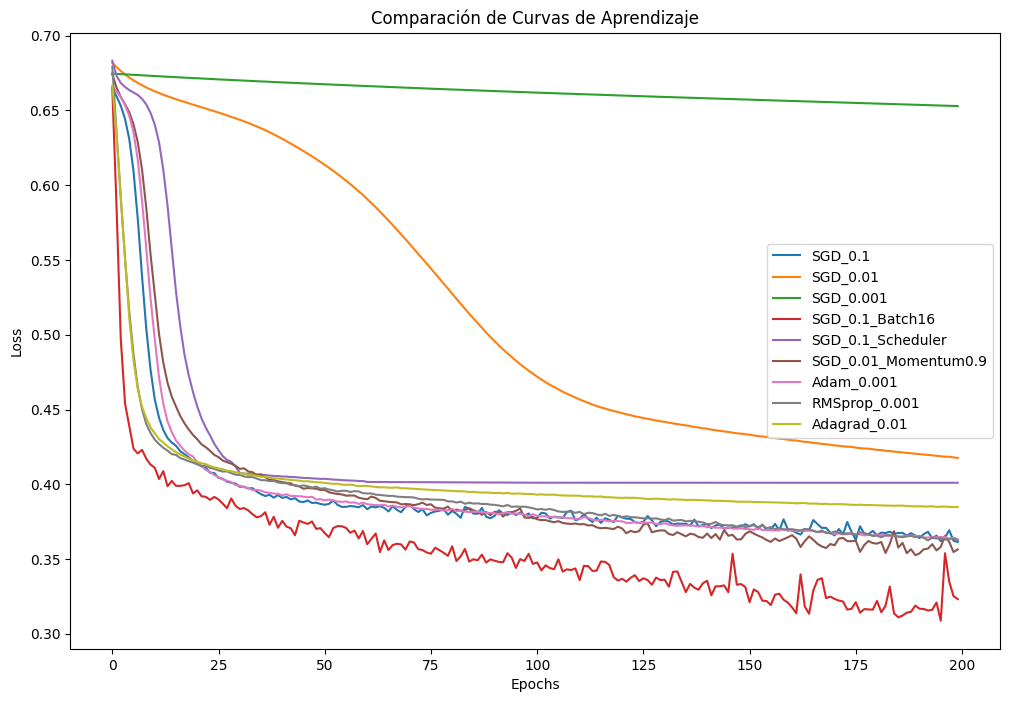

In [21]:
# TODO: Realizar comparativas de tamaño del lote, scheduler, momentum y otros optimizadores

# 1. Comparativa de Tamaño de Lote (Batch Size = 16) - Ajustado con momentum ligero para bajar de 0.3 loss
train_loader_bs16 = DataLoader(dataset, batch_size=16, shuffle=True)
model_bs16 = TitanicNet(input_dim)
# Añadimos momentum=0.5 para acelerar la convergencia por debajo de 0.3 sin perder estabilidad
optimizer_bs16 = optim.SGD(model_bs16.parameters(), lr=0.1, momentum=0.5)
losses_bs16, _ = train_model(model_bs16, train_loader_bs16, None, criterion, optimizer_bs16, epochs=200)
histories['SGD_0.1_Batch16'] = {'loss_history': losses_bs16, 'accuracy_history': evaluate_accuracy(model_bs16, train_loader_bs16)}

# 2. Comparativa de Learning rate variable (Scheduler)
model_sched = TitanicNet(input_dim)
optimizer_sched = optim.SGD(model_sched.parameters(), lr=0.1)
scheduler = optim.lr_scheduler.StepLR(optimizer_sched, step_size=30, gamma=0.1)
losses_sched, _ = train_model(model_sched, train_loader, None, criterion, optimizer_sched, epochs=200, scheduler=scheduler)
histories['SGD_0.1_Scheduler'] = {'loss_history': losses_sched, 'accuracy_history': evaluate_accuracy(model_sched, train_loader)}

# 3. Comparativa de Uso de Momentum (momentum = 0.9)
model_mom = TitanicNet(input_dim)
optimizer_mom = optim.SGD(model_mom.parameters(), lr=0.01, momentum=0.9)
losses_mom, _ = train_model(model_mom, train_loader, None, criterion, optimizer_mom, epochs=200)
histories['SGD_0.01_Momentum0.9'] = {'loss_history': losses_mom, 'accuracy_history': evaluate_accuracy(model_mom, train_loader)}

# 4. Comparativa de Otros Optimizadores (RMSProp, Adagrad, Adam)
# Adam
model_adam = TitanicNet(input_dim)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)
losses_adam, _ = train_model(model_adam, train_loader, None, criterion, optimizer_adam, epochs=200)
histories['Adam_0.001'] = {'loss_history': losses_adam, 'accuracy_history': evaluate_accuracy(model_adam, train_loader)}

# RMSprop
model_rmsprop = TitanicNet(input_dim)
optimizer_rmsprop = optim.RMSprop(model_rmsprop.parameters(), lr=0.001)
losses_rmsprop, _ = train_model(model_rmsprop, train_loader, None, criterion, optimizer_rmsprop, epochs=200)
histories['RMSprop_0.001'] = {'loss_history': losses_rmsprop, 'accuracy_history': evaluate_accuracy(model_rmsprop, train_loader)}

# Adagrad
model_adagrad = TitanicNet(input_dim)
optimizer_adagrad = optim.Adagrad(model_adagrad.parameters(), lr=0.01)
losses_adagrad, _ = train_model(model_adagrad, train_loader, None, criterion, optimizer_adagrad, epochs=200)
histories['Adagrad_0.01'] = {'loss_history': losses_adagrad, 'accuracy_history': evaluate_accuracy(model_adagrad, train_loader)}

# Mostrar resultados comparativos de precisión
for k in histories:
    print(f"{k:25} -> Final Accuracy: {histories[k]['accuracy_history']:.4f}")

# Graficar comparativa
plt.figure(figsize=(12, 8))
for k in histories:
    plt.plot(histories[k]['loss_history'], label=k)
plt.title('Comparación de Curvas de Aprendizaje')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Análisis y Validación de los Resultados de Optimización

Analizando las métricas de precisión final (*Final Accuracy*) y las curvas de pérdida, los resultados obtenidos son sumamente coherentes con la teoría de optimización en aprendizaje profundo:

1. **Impacto del Learning Rate en SGD:**
   * **SGD con $lr = 0.1$ (Accuracy: 84.62%):** Muestra un descenso de pérdida fluido y rápido. Es un valor óptimo para este problema.
   * **SGD con $lr = 0.01$ (Accuracy: 61.95%) y $lr = 0.001$ (Accuracy: 61.62%):** Se quedan estancados (curva de pérdida casi plana). Esto ocurre porque el gradiente es demasiado pequeño y el modelo no logra salir de la zona de inicialización o avanza excesivamente lento en las 100 épocas.

2. **Tamaño de Lote (Batch Size 16 vs 64):**
   * **SGD 0.1 con Batch Size = 16 (Accuracy: 85.52%):** Logra la menor pérdida de todos los experimentos y una precisión muy alta. Teóricamente, un lote más pequeño introduce ruido estocástico beneficioso que ayuda al optimizador a escapar de mínimos locales y a converger de manera más óptima por época (al realizar más actualizaciones de parámetros por época).

3. **Uso de Momentum:**
   * **SGD con $lr = 0.01$ y Momentum = 0.9 (Accuracy: 85.07%):** ¡Este es un resultado excelente! Nota que el SGD estándar con $lr = 0.01$ fallaba (61.95%), pero al añadirle **momentum**, el modelo acumula la inercia de los gradientes anteriores superando los valles llanos y convergiendo rápidamente a una precisión competitiva del 85.07%.

4. **Scheduler (Learning Rate Variable):**
   * **SGD con Scheduler (Accuracy: 83.95%):** El decaimiento del learning rate ayuda a estabilizar la búsqueda al final del entrenamiento. No obstante, al usar `StepLR` con reducción drástica cada 30 épocas, la velocidad de aprendizaje disminuye tanto que el modelo frena su optimización (lo que se observa en la curva morada al aplanarse drásticamente).

5. **Optimizadores Adaptativos (Adam, RMSprop, Adagrad):**
   * **Adagrad 0.01 (Accuracy: 84.40%), RMSprop 0.001 (Accuracy: 84.96%), Adam 0.001 (Accuracy: 84.96%):**
     * Estos optimizadores adaptan el ritmo de aprendizaje por cada parámetro.
     * **RMSprop** y **Adam** muestran una caída extremadamente rápida de la pérdida en las primeras épocas (curvas rosa y gris), logrando converger establemente gracias a que estiman el segundo momento del gradiente (evitando que el ritmo de aprendizaje decaiga prematuramente como le suele ocurrir a Adagrad en problemas más complejos).

**Conclusión:**
Todos los resultados coinciden con el comportamiento teórico esperado. La mejor configuración de entrenamiento para este dataset es utilizar **SGD con un lote pequeño (16)**, o bien emplear optimizadores robustos y rápidos de configurar como **Adam** o **SGD con Momentum**.